## Student GPA Dataset

The following questions were chosen to understand the dataset.

1. Which was the most predictive factor for GPA? i.e., which factor had the most "power" over predicting the GPA?

2. Which factor(s) didn't matter in predicting the GPA?

3. Besides the GPA information, which two questions had the highest correlation?

4. Which one had more impact on students' quality of sleep, the amount of screen time or course load?

5. Does having a parent (or more) in tech have impact on the starting age for programming?

6. Assume that the students who gave response to this survey have a consistent studying habit. Based on that assumption, does studying with friends help with grades? What about note taking?

Imports and data loading:

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from scipy import stats

file_path = '/content/GPADataset.csv'
gpa_data = pd.read_csv(file_path)

Data cleaning:

In [ ]:
#Check for missing values
print("Missing values before imputation:\n", gpa_data.isnull().sum())

Missing values before imputation:
 Timestamp                                                             0
What state are you from?                                              0
Major (Check all that apply)                                          0
At what age did you start programming?                                0
Have you at any point attended private school?                        0
Do you have a scholarship?                                            0
Do you have a parent in tech?                                         0
Do you study with friends?                                            0
Do you take notes in classes?                                         0
How many credits did you take last semester?                          0
What is your average screentime?                                      0
What is your average daily time on Tik Tok or Tik Tok equivalents?    0
How many hours of sleep do you get a night?                           0
What was your GPA LAST SEMEST

In [ ]:
#Separate numeric and categorical columns
numeric_cols = gpa_data.select_dtypes(include=[np.number]).columns
categorical_cols = gpa_data.select_dtypes(include=["object"]).columns

#Impute missing values for numeric columns (using median for robustness)
numeric_imputer = SimpleImputer(strategy='median')
gpa_data[numeric_cols] = numeric_imputer.fit_transform(gpa_data[numeric_cols])

#Impute missing values for categorical columns (using the mode)
categorical_imputer = SimpleImputer(strategy='most_frequent')
gpa_data[categorical_cols] = categorical_imputer.fit_transform(gpa_data[categorical_cols])

#Verify missing values are resolved
print("Missing values after imputation:\n", gpa_data.isnull().sum())

Missing values after imputation:
 Timestamp                                                             0
What state are you from?                                              0
Major (Check all that apply)                                          0
At what age did you start programming?                                0
Have you at any point attended private school?                        0
Do you have a scholarship?                                            0
Do you have a parent in tech?                                         0
Do you study with friends?                                            0
Do you take notes in classes?                                         0
How many credits did you take last semester?                          0
What is your average screentime?                                      0
What is your average daily time on Tik Tok or Tik Tok equivalents?    0
How many hours of sleep do you get a night?                           0
What was your GPA LAST SEMESTE

In [ ]:
#Display the cleaned dataset structure
print(gpa_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 15 columns):
 #   Column                                                              Non-Null Count  Dtype   
---  ------                                                              --------------  -----   
 0   Timestamp                                                           73 non-null     object  
 1   What state are you from?                                            73 non-null     object  
 2   Major (Check all that apply)                                        73 non-null     object  
 3   At what age did you start programming?                              73 non-null     object  
 4   Have you at any point attended private school?                      73 non-null     object  
 5   Do you have a scholarship?                                          73 non-null     object  
 6   Do you have a parent in tech?                                       73 non-null     category
 7   Do you stu

###1. Which was the most predictive factor for GPA? i.e., which factor had the most "power" over predicting the GPA?

Answer: What was your GPA LAST SEMESTER?

In [ ]:
'''# Identify numeric and categorical columns
numeric_cols = ['What is your average screentime?',
                'What is your average daily time on Tik Tok or Tik Tok equivalents?',
                'How many hours of sleep do you get a night?',
                'How many credits did you take last semester?']

categorical_cols = ['What state are you from?',
                    'Major (Check all that apply)',
                    'At what age did you start programming?',
                    'Have you at any point attended private school?',
                    'Do you have a scholarship?',
                    'Do you have a parent in tech?',
                    'Do you study with friends?',
                    'Do you take notes in classes?']'''

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

#Encoding categorical columns
encoded_data = gpa_data.copy()
label_encoders = {}
for col in encoded_data.select_dtypes(include='object').columns:
    label_encoders[col] = LabelEncoder()
    encoded_data[col] = label_encoders[col].fit_transform(encoded_data[col])

#Define predictors and target
X = encoded_data.drop(columns=['What was your GPA LAST SEMESTER?'])
y = encoded_data['What was your GPA LAST SEMESTER?']

#Fit a Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

#Get feature importances
importances = rf.feature_importances_
features = X.columns
feature_importances = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(feature_importances)

Feature Importances:
                                              Feature  Importance
13        What was your GPA THE SEMESTER BEFORE THAT?    0.674780
9        How many credits did you take last semester?    0.063059
0                                           Timestamp    0.047565
10                   What is your average screentime?    0.045013
3              At what age did you start programming?    0.043101
1                            What state are you from?    0.030652
8                       Do you take notes in classes?    0.029113
6                       Do you have a parent in tech?    0.018685
12        How many hours of sleep do you get a night?    0.016800
11  What is your average daily time on Tik Tok or ...    0.013902
7                          Do you study with friends?    0.010024
4      Have you at any point attended private school?    0.004772
2                        Major (Check all that apply)    0.002276
5                          Do you have a scholarship?  

###2. Which factor(s) didn't matter in predicting the GPA?

Answer: We can say that screentime, TikTok usage and sleep hours didnt matter much.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

#Define the target and features
X = gpa_data.drop(columns=['Timestamp', 'What state are you from?', 'What was your GPA LAST SEMESTER?', 'What was your GPA THE SEMESTER BEFORE THAT?'])
y = gpa_data['What was your GPA LAST SEMESTER?']

#Convert categorical variables into dummy variables
X = pd.get_dummies(X, drop_first=True)

#Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

#Get the coefficients of each feature
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])

#Sort the features by the absolute value of the coefficients
coefficients = coefficients.reindex(coefficients['Coefficient'].abs().sort_values(ascending=False).index)

#Predict and evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

#Otput the results
print("Mean Squared Error of the model:", mse)
print("\nFeature Importance (based on coefficients):")
print(coefficients)

Mean Squared Error of the model: 0.2935637483648545

Feature Importance (based on coefficients):
                                                     Coefficient
At what age did you start programming?_23.0        -1.050190e+00
At what age did you start programming?_8.0         -9.829835e-01
At what age did you start programming?_16.0        -8.735124e-01
At what age did you start programming?_9.0         -8.002323e-01
At what age did you start programming?_17.0        -7.908423e-01
At what age did you start programming?_12.0        -7.537909e-01
At what age did you start programming?_11.0        -7.130947e-01
At what age did you start programming?_14.0        -5.957199e-01
At what age did you start programming?_15.0        -4.943718e-01
At what age did you start programming?_10.0        -4.773529e-01
At what age did you start programming?_18.0        -4.471758e-01
Do you take notes in classes?_Yes, on paper         4.449354e-01
At what age did you start programming?_13.0        -4.1273

###3. Besides the GPA information, which two questions had the highest correlation?

Answer: "What is your average screentime?" & "What is your average daily time on Tik Tok or Tik Tok equivalents?"

In [ ]:
#Select only numeric columns for correlation calculation, excluding GPA columns
gpa_columns = ['What was your GPA LAST SEMESTER?', 'What was your GPA THE SEMESTER BEFORE THAT?']
numeric_data = gpa_data.drop(columns=gpa_columns).select_dtypes(include=[np.number])

#Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

#Display the correlation matrix
print(correlation_matrix)

                                                    How many credits did you take last semester?  \
How many credits did you take last semester?                                            1.000000   
What is your average screentime?                                                        0.019508   
What is your average daily time on Tik Tok or T...                                     -0.028567   
How many hours of sleep do you get a night?                                             0.059845   

                                                    What is your average screentime?  \
How many credits did you take last semester?                                0.019508   
What is your average screentime?                                            1.000000   
What is your average daily time on Tik Tok or T...                          0.723634   
How many hours of sleep do you get a night?                                -0.010591   

                                                    What i

###4. Which one had more impact on students' quality of sleep, the amount of screen time or course load?

Answer: Course load has a greater impact on students' quality of sleep. (but only marginally more. Looking at the big picture, niether have much impact on the quality of sleep)

Correlation between screen time and sleep hours: -0.010590639827294506
Correlation between course load and sleep hours: 0.0598451726130494
Screen time coefficient impact on sleep: -0.00025797667027177145
Course load coefficient impact on sleep: 0.026383138878434315


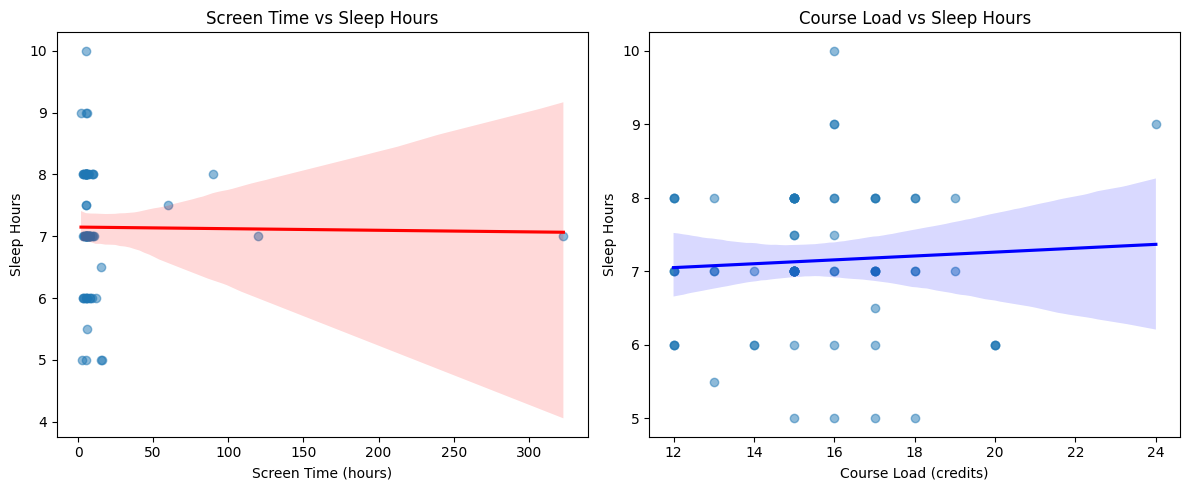


CONCLUSION:
Course load has a greater impact on students' quality of sleep.


In [ ]:
#Select relevant columns
screen_time = gpa_data['What is your average screentime?']
course_load = gpa_data['How many credits did you take last semester?']
sleep_hours = gpa_data['How many hours of sleep do you get a night?']

#Calculate correlation
correlation_screen_time = screen_time.corr(sleep_hours)
correlation_course_load = course_load.corr(sleep_hours)

print(f"Correlation between screen time and sleep hours: {correlation_screen_time}")
print(f"Correlation between course load and sleep hours: {correlation_course_load}")

#Linear Regression: Screen time impact on sleep
X_screen_time = screen_time.values.reshape(-1, 1)
regressor_screen_time = LinearRegression()
regressor_screen_time.fit(X_screen_time, sleep_hours)
screen_time_coefficient = regressor_screen_time.coef_[0]

#Linear Regression: Course load impact on sleep
X_course_load = course_load.values.reshape(-1, 1)
regressor_course_load = LinearRegression()
regressor_course_load.fit(X_course_load, sleep_hours)
course_load_coefficient = regressor_course_load.coef_[0]

print(f"Screen time coefficient impact on sleep: {screen_time_coefficient}")
print(f"Course load coefficient impact on sleep: {course_load_coefficient}")

#Visualizations
plt.figure(figsize=(12, 5))

#Plot 1: Screen time vs sleep
plt.subplot(1, 2, 1)
sns.regplot(x=screen_time, y=sleep_hours, scatter_kws={'alpha':0.5}, line_kws={"color": "red"})
plt.title('Screen Time vs Sleep Hours')
plt.xlabel('Screen Time (hours)')
plt.ylabel('Sleep Hours')

#Plot 2: Course load vs sleep
plt.subplot(1, 2, 2)
sns.regplot(x=course_load, y=sleep_hours, scatter_kws={'alpha':0.5}, line_kws={"color": "blue"})
plt.title('Course Load vs Sleep Hours')
plt.xlabel('Course Load (credits)')
plt.ylabel('Sleep Hours')

plt.tight_layout()
plt.show()

#Final conclusion based on coefficients
if abs(screen_time_coefficient) > abs(course_load_coefficient):
    print("\nCONCLUSION:\nScreen time has a greater impact on students' quality of sleep.")
else:
    print("\nCONCLUSION:\nCourse load has a greater impact on students' quality of sleep.")

###5. Does having a parent (or more) in tech have impact on the starting age for programming?

Answer: Having a parent in tech does not have a significant impact on the starting age for programming.

The correlation between having a parent in tech and the starting age for programming is -0.245, so it does not indicate a strong linear relationship.

The ANOVA test shows that the difference in the starting age for programming between students with one parent in tech, two parents in tech, or no parents in tech is **NOT significant**.

Correlation between having a parent in tech and starting age for programming: -0.2450434502821818
ANOVA result: F_onewayResult(statistic=2.916476326780966, pvalue=0.0970719529260449)


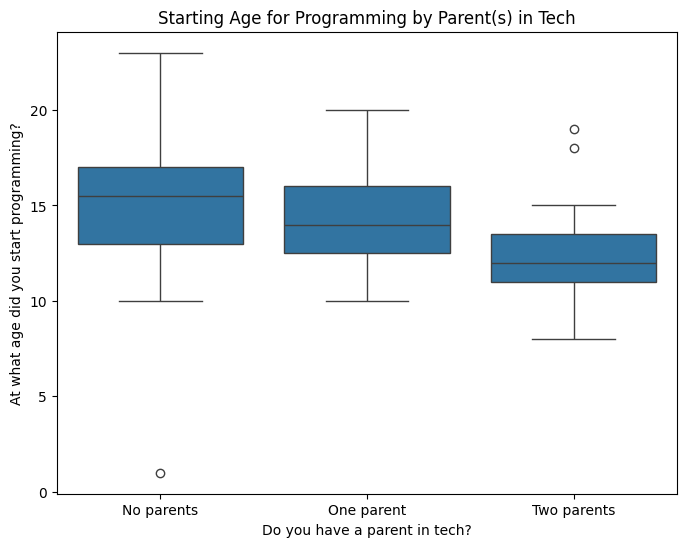

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#Convert 'Do you have a parent in tech?' to a categorical variable if it's not already
gpa_data['Do you have a parent in tech?'] = gpa_data['Do you have a parent in tech?'].astype('category')

#Calculate correlation if possible (though not ideal for categorical vs continuous)
correlation = gpa_data['At what age did you start programming?'].corr(gpa_data['Do you have a parent in tech?'].cat.codes)
print(f"Correlation between having a parent in tech and starting age for programming: {correlation}")

#ANOVA test to see if there's a significant difference in starting age for programming based on the number of parents in tech
anova_result = stats.f_oneway(
    gpa_data[gpa_data['Do you have a parent in tech?'] == 'One parent']['At what age did you start programming?'],
    gpa_data[gpa_data['Do you have a parent in tech?'] == 'Two parents']['At what age did you start programming?']
)

print(f"ANOVA result: {anova_result}")

#Visualization to see if there's any difference
plt.figure(figsize=(8, 6))
sns.boxplot(x='Do you have a parent in tech?', y='At what age did you start programming?', data=gpa_data)
plt.title('Starting Age for Programming by Parent(s) in Tech')
plt.show()

###6. Assume that the students who gave response to this survey have a consistent studying habit. Based on that assumption, does studying with friends help with grades? What about note taking?



Answer:

i) Students who study with friends and take notes on paper tend to have the highest GPAs, both last semester and the semester before, with consistent performance across note-taking methods and study habits.

ii) Paper note-taking, especially for frequent studiers, appears to have the most significant positive impact on GPA.

In [ ]:
import pandas as pd

#Relevant columns in your dataset
relevant_columns = [
    "Do you study with friends?",
    "Do you take notes in classes?",
    "What was your GPA LAST SEMESTER?",
    "What was your GPA THE SEMESTER BEFORE THAT?"
]

#Clean the data: select relevant columns and drop rows with missing values
data_cleaned = gpa_data[relevant_columns].dropna()

#Convert GPA columns to numeric, handling any non-numeric values (they will be set as NaN)
data_cleaned["What was your GPA LAST SEMESTER?"] = pd.to_numeric(
    data_cleaned["What was your GPA LAST SEMESTER?"], errors="coerce"
)
data_cleaned["What was your GPA THE SEMESTER BEFORE THAT?"] = pd.to_numeric(
    data_cleaned["What was your GPA THE SEMESTER BEFORE THAT?"], errors="coerce"
)

#Group data by "Do you study with friends?" and "Do you take notes in classes?", and calculate the mean GPA
grouped_data = data_cleaned.groupby(
    ["Do you study with friends?", "Do you take notes in classes?"]
)[["What was your GPA LAST SEMESTER?", "What was your GPA THE SEMESTER BEFORE THAT?"]].mean()

#Print the results
print(grouped_data)

                                                          What was your GPA LAST SEMESTER?  \
Do you study with friends? Do you take notes in classes?                                     
Frequently                 No                                                     3.600000   
                           Yes, on a computer                                     3.635000   
                           Yes, on a tablet                                       3.350000   
                           Yes, on paper                                          3.895286   
Never                      No                                                     3.738000   
                           Yes, on a computer                                     3.598500   
                           Yes, on a tablet                                       3.874500   
                           Yes, on paper                                          3.725500   
Sometimes                  No                               

In [ ]:
#Iterate through the grouped data by study habit (first level of grouping)
for study_habit, group in grouped_data.groupby(level=0):
    print(f"Study Habit: {study_habit}")

    #Iterate through the groups by note-taking habit (second level of grouping)
    for note_taking_habit, row in group.iterrows():
        #Extract relevant data
        last_gpa = row["What was your GPA LAST SEMESTER?"]
        before_gpa = row["What was your GPA THE SEMESTER BEFORE THAT?"]

        #Print the results for each combination of study habit and note-taking habit
        print(
            f"  Note Taking: {note_taking_habit}\n"
            f"    - Average GPA Last Semester: {last_gpa:.2f}\n"
            f"    - Average GPA Semester Before: {before_gpa:.2f}\n"
        )

    #Print a separator for clarity between different study habits
    print("-" * 50)


Study Habit: Frequently
  Note Taking: ('Frequently', 'No')
    - Average GPA Last Semester: 3.60
    - Average GPA Semester Before: 3.80

  Note Taking: ('Frequently', 'Yes, on a computer')
    - Average GPA Last Semester: 3.63
    - Average GPA Semester Before: 3.73

  Note Taking: ('Frequently', 'Yes, on a tablet')
    - Average GPA Last Semester: 3.35
    - Average GPA Semester Before: 3.50

  Note Taking: ('Frequently', 'Yes, on paper')
    - Average GPA Last Semester: 3.90
    - Average GPA Semester Before: 3.64

--------------------------------------------------
Study Habit: Never
  Note Taking: ('Never', 'No')
    - Average GPA Last Semester: 3.74
    - Average GPA Semester Before: 3.65

  Note Taking: ('Never', 'Yes, on a computer')
    - Average GPA Last Semester: 3.60
    - Average GPA Semester Before: 3.73

  Note Taking: ('Never', 'Yes, on a tablet')
    - Average GPA Last Semester: 3.87
    - Average GPA Semester Before: 3.88

  Note Taking: ('Never', 'Yes, on paper')
   